In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
df = pd.read_csv("../data/raw/TelcoCustomer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [15]:
print(df["Churn"].value_counts(normalize=True)*100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


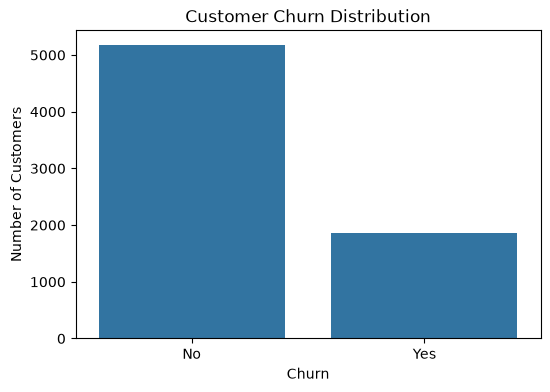

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


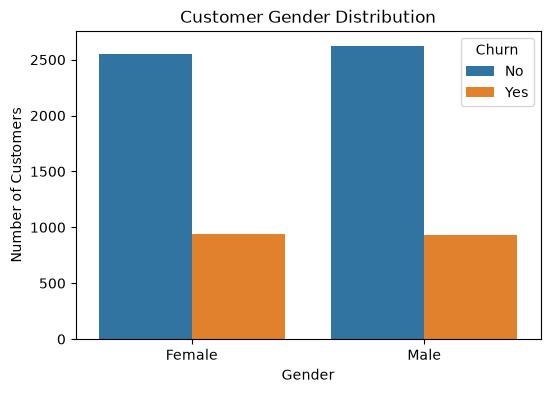

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="gender",hue="Churn")

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

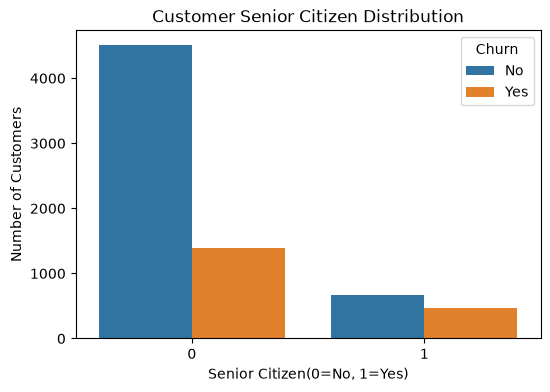

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="SeniorCitizen",hue="Churn")

plt.title("Customer Senior Citizen Distribution")
plt.xlabel("Senior Citizen(0=No, 1=Yes)")
plt.ylabel("Number of Customers")
plt.show()

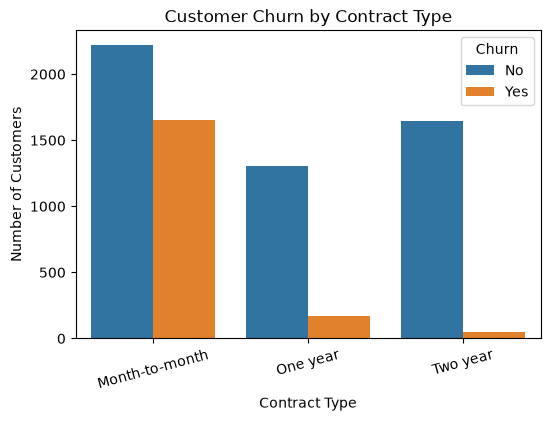

In [20]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Contract",hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

In [21]:
contract_churn=pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index')*100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


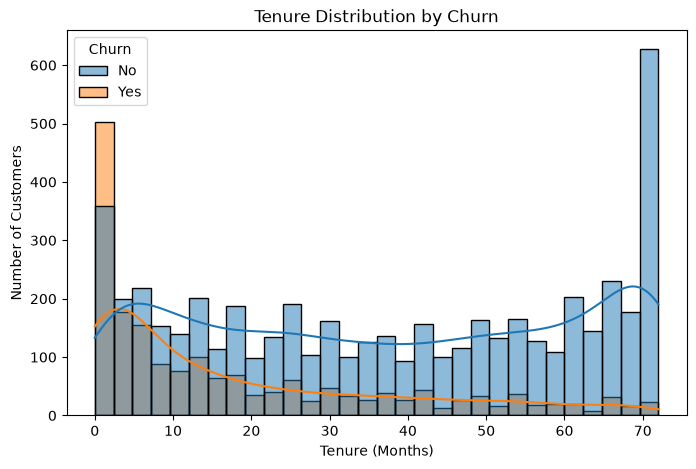

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

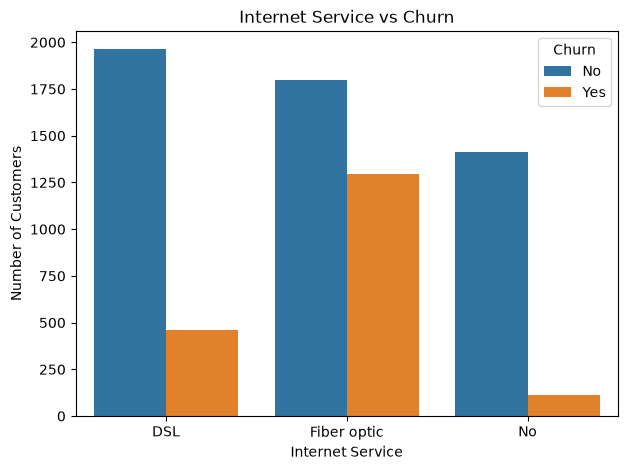

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

In [24]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [25]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [26]:
print("Missing values in TotalCharges:",df["TotalCharges"].isnull().sum())

Missing values in TotalCharges: 11


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [28]:
df=df.dropna(subset=["TotalCharges"])

In [29]:
print("Dataset shape after removing missing TotalCharges:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

Dataset shape after removing missing TotalCharges:
(7032, 21)

Missing values:
0


In [30]:
df.shape

(7032, 21)

In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [32]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.dtypes)

X shape: (7032, 20)
y shape: (7032,)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [33]:
y=df["Churn"].map({"No":0,"Yes":1})
print(y.value_counts)
print(y.isnull().sum())

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64>
0


In [34]:
categorical_cols = X.select_dtypes(include="str").columns

print(categorical_cols)
print("Number of categorical columns:", len(categorical_cols))

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')
Number of categorical columns: 16


In [35]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (7032, 20)
Encoded X shape: (7032, 7061)


In [36]:
print(X_encoded.dtypes.value_counts())

int64      7059
float64       2
Name: count, dtype: int64


TRAIN-TEST

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 7061)
X_test: (1407, 7061)
y_train: (5625,)
y_test: (1407,)


LOGISTIC REGRESSION

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!\n")

y_predict_lr = log_model.predict(X_test)

print(y_predict_lr[:20],"\n")

accuracy_log = accuracy_score(y_test, y_predict_lr)

print("Logistic Regression Accuracy:", accuracy_log)

print("\nClassification Report:")
print(classification_report(y_test, y_predict_lr))

Logistic Regression model trained successfully!

[0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 0] 

Logistic Regression Accuracy: 0.7938877043354655

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1033
           1       0.62      0.58      0.60       374

    accuracy                           0.79      1407
   macro avg       0.74      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



d:\customer-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


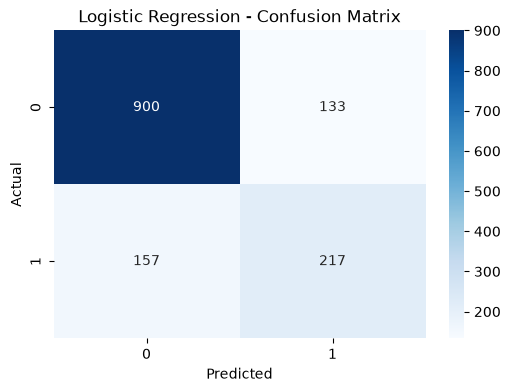

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_predict_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

DECISION TREE

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

y_predict_dt=model.predict(X_test)

accuracy_dt=accuracy_score(y_test,y_predict_dt)
print("Decision Tree Accuracy:",accuracy_dt)

print("\nClassification Report:")
print(classification_report(y_test,y_predict_dt))

Decision Tree model trained successfully!
Decision Tree Accuracy: 0.7782515991471215

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



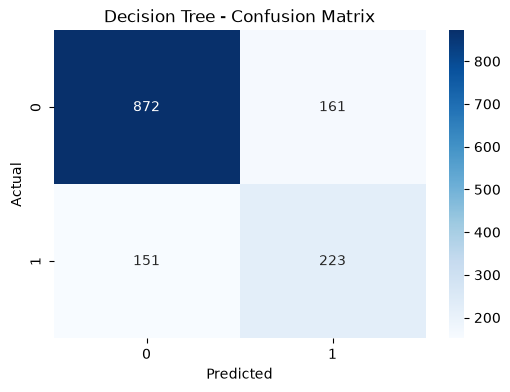

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_predict_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

RANDOM FOREST

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

y_predict_rf = model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_predict_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_predict_rf))

Random Forest model trained successfully!
Random Forest Accuracy: 0.7945984363894811

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.47      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



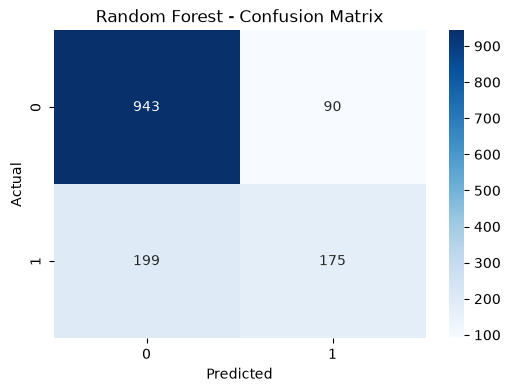

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_predict_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [59]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

print("KNN model trained successfully!")

y_predict_knn = model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_predict_knn)

print("KNN Accuracy:", accuracy_knn)
print(classification_report(y_test, y_predict_knn))

KNN model trained successfully!
KNN Accuracy: 0.746268656716418
              precision    recall  f1-score   support

           0       0.81      0.86      0.83      1033
           1       0.53      0.43      0.47       374

    accuracy                           0.75      1407
   macro avg       0.67      0.64      0.65      1407
weighted avg       0.73      0.75      0.74      1407



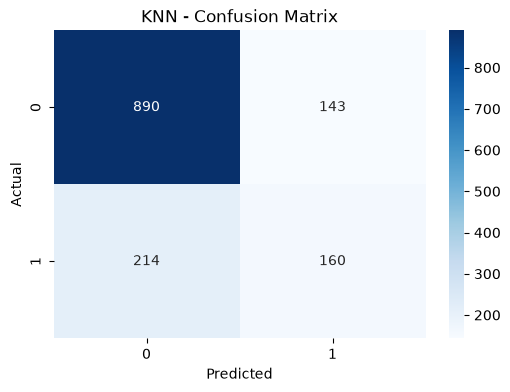

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_predict_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")
plt.show()

In [61]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

y_predict_gnb = model.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_predict_gnb)

print("Naive Bayes Accuracy:", accuracy_nb)
print(classification_report(y_test, y_predict_gnb))

Naive Bayes model trained successfully!
Naive Bayes Accuracy: 0.6076759061833689
              precision    recall  f1-score   support

           0       0.94      0.50      0.65      1033
           1       0.40      0.91      0.55       374

    accuracy                           0.61      1407
   macro avg       0.67      0.70      0.60      1407
weighted avg       0.79      0.61      0.62      1407



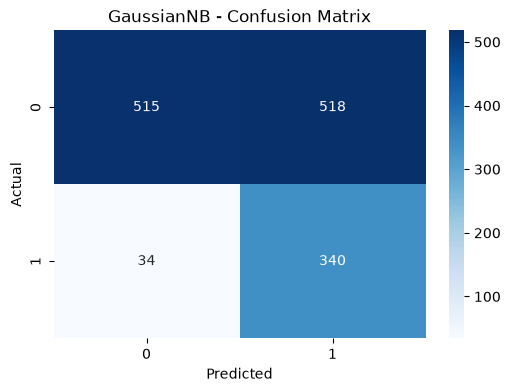

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_gnb = confusion_matrix(y_test, y_predict_gnb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GaussianNB - Confusion Matrix")
plt.show()

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Calculate metrics for each model
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Naive Bayes"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_predict_lr),
        accuracy_score(y_test, y_predict_dt),
        accuracy_score(y_test, y_predict_rf),
        accuracy_score(y_test, y_predict_knn),
        accuracy_score(y_test, y_predict_gnb)
    ],
    
    "Precision": [
        precision_score(y_test, y_predict_lr),
        precision_score(y_test, y_predict_dt),
        precision_score(y_test, y_predict_rf),
        precision_score(y_test, y_predict_knn),
        precision_score(y_test, y_predict_gnb)
    ],
    
    "Recall": [
        recall_score(y_test, y_predict_lr),
        recall_score(y_test, y_predict_dt),
        recall_score(y_test, y_predict_rf),
        recall_score(y_test, y_predict_knn),
        recall_score(y_test, y_predict_gnb)
    ],
    
    "F1-Score": [
        f1_score(y_test, y_predict_lr),
        f1_score(y_test, y_predict_dt),
        f1_score(y_test, y_predict_rf),
        f1_score(y_test, y_predict_knn),
        f1_score(y_test, y_predict_gnb)
    ]
}

comparison_df = pd.DataFrame(results)

print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.793888   0.620000  0.580214  0.599448
1        Decision Tree  0.778252   0.580729  0.596257  0.588391
2        Random Forest  0.794598   0.660377  0.467914  0.547731
3                  KNN  0.746269   0.528053  0.427807  0.472674
4          Naive Bayes  0.607676   0.396270  0.909091  0.551948


In [45]:
import joblib
import os

os.makedirs("../artifacts", exist_ok=True)

joblib.dump(log_model, "../artifacts/churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [46]:
joblib.dump(X_encoded.columns.tolist(), "../artifacts/feature_names.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


In [47]:
numerical_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

joblib.dump(numerical_cols, "../artifacts/numerical_cols.pkl")

print("Numerical columns saved successfully!")

Numerical columns saved successfully!
